# Week 5 Task: Deep Learning Application in Data Science
## Iris Flower Classification using Neural Networks (TensorFlow/Keras)

**Objective:** Explore the fundamentals of deep learning and apply these concepts to solve a multi-class classification problem using a neural network built with TensorFlow/Keras on the classic Iris dataset.

This notebook demonstrates the complete workflow: data loading & exploration, preprocessing, model architecture design, training, evaluation, and critical analysis of results.

## 1. Import Required Libraries

Starting by importing the necessary Python libraries. Each library serves a specific purpose in the deep learning pipeline.

In [1]:
!pip install tensorflow

In [14]:
# Import fundamental data handling libraries
import numpy as np                  # For numerical operations and array handling
import pandas as pd                 # For data loading, exploration and manipulation

# Visualization libraries
import matplotlib.pyplot as plt     # For creating plots (loss curves, accuracy curves, etc.)
import seaborn as sns               # For advanced statistical visualizations (confusion matrix heatmap)

# Deep Learning framework - Keras with TensorFlow backend
import keras                        # High-level deep learning API
from keras.models import Sequential # Sequential model for stacking layers linearly
from keras.layers import Dense, Dropout  # Dense = fully connected layer; Dropout for regularization
from keras.utils import to_categorical   # To convert integer labels into one-hot encoded vectors
from keras.callbacks import EarlyStopping, ReduceLROnPlateau  # Callbacks to improve training

# Set random seeds for reproducibility (so results stay consistent across runs)
np.random.seed(42)
keras.utils.set_random_seed(42)

print("Libraries imported successfully!")
print(f"Keras version: {keras.__version__}")
print(f"Backend: {keras.backend.backend()}")

Libraries imported successfully!
Keras version: 3.16.0.dev2026100504
Backend: tensorflow


## 2. Load and Explore the Dataset

**Dataset Choice Justification:**  
The Iris dataset is a publicly available, classic multi-class classification problem. It contains 150 samples of iris flowers with 4 numerical features (sepal length/width, petal length/width) and 3 species classes. It is ideal for demonstrating neural network fundamentals because:
- Small size → fast training, easy to experiment
- Clean data → focus on model design rather than heavy preprocessing
- Well-separated classes → good baseline for learning decision boundaries
- Publicly available from UCI Machine Learning Repository

In [15]:
# Load the Iris dataset directly from the UCI Machine Learning Repository
# This ensures we use a publicly available source as required by the task
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

# Column names are not present in the file, so we define them manually
column_names = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(url, header=None, names=column_names)

# Display basic information about the dataset
print("Dataset Shape (rows, columns):", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nClass Distribution:")
print(df["species"].value_counts())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape (rows, columns): (150, 5)

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.9 KB

Class Distribution:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Statistical Summary:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 3. Data Visualization & Exploratory Data Analysis (EDA)

Before building a model, we visualize the data to understand relationships between features and classes. This helps in justifying architecture choices later.

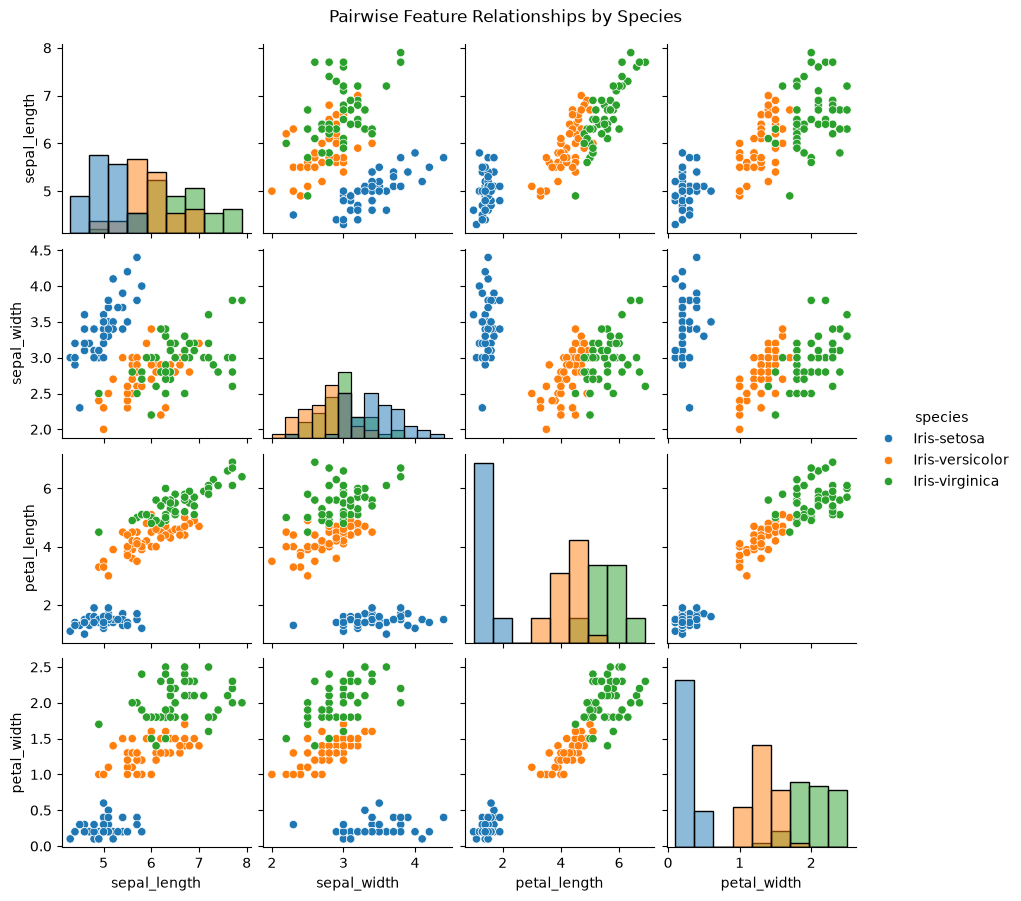

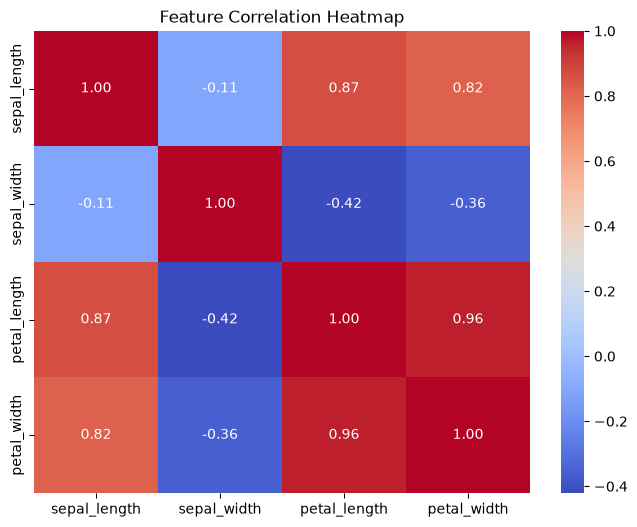

In [16]:
# Pairplot to visualize relationships between all features colored by species
# This helps us see how well-separated the classes are in feature space
sns.pairplot(df, hue="species", diag_kind="hist", height=2.2)
plt.suptitle("Pairwise Feature Relationships by Species", y=1.02)
plt.show()

# Correlation heatmap of numerical features
plt.figure(figsize=(8, 6))
sns.heatmap(df.iloc[:, :-1].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

**EDA Insights:**  
- Petal length and petal width show strong positive correlation and clear separation between species.
- Setosa is linearly separable from the other two classes.
- Versicolor and Virginica have some overlap, which a neural network can learn non-linear boundaries for.

## 4. Data Preprocessing

Neural networks work best with numerical inputs and properly scaled features. We also convert the categorical target into one-hot encoded format.

In [17]:
# Separate features (X) and target (y)
X = df.iloc[:, :-1].values          # All rows, first 4 columns → feature matrix
y = df["species"].values            # Target labels (species names)

# Encode species names into integer labels (0, 1, 2)
# We do this manually to avoid dependency on scikit-learn
species_mapping = {"Iris-setosa": 0, "Iris-versicolor": 1, "Iris-virginica": 2}
y_encoded = np.array([species_mapping[label] for label in y])

print("Feature matrix shape:", X.shape)
print("Encoded labels (first 10):", y_encoded[:10])
print("Unique classes:", np.unique(y_encoded))

# Convert integer labels to one-hot encoding
# Example: 0 → [1, 0, 0], 1 → [0, 1, 0], 2 → [0, 0, 1]
# This is required because our final layer will use softmax activation for multi-class classification
y_onehot = to_categorical(y_encoded, num_classes=3)
print("\nOne-hot encoded labels shape:", y_onehot.shape)
print("Example one-hot vectors:\n", y_onehot[:5])

Feature matrix shape: (150, 4)
Encoded labels (first 10): [0 0 0 0 0 0 0 0 0 0]
Unique classes: [0 1 2]

One-hot encoded labels shape: (150, 3)
Example one-hot vectors:
 [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [18]:
# Manual train-test split (80% train, 20% test) without scikit-learn
# We shuffle the data first to ensure random distribution of classes
indices = np.arange(X.shape[0])
np.random.shuffle(indices)

split_idx = int(0.8 * len(indices))   # 80% for training
train_idx, test_idx = indices[:split_idx], indices[split_idx:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y_onehot[train_idx], y_onehot[test_idx]
y_train_int, y_test_int = y_encoded[train_idx], y_encoded[test_idx]  # Keep integer labels for later metrics

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Feature Scaling (Standardization)
# Neural networks converge faster and more stably when features have mean ≈ 0 and std ≈ 1
# We compute mean and std ONLY from the training set to avoid data leakage
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std   # Use same mean/std from training set

print("\nFeature means after scaling (should be ~0):", X_train_scaled.mean(axis=0).round(5))
print("Feature stds after scaling (should be ~1):", X_train_scaled.std(axis=0).round(5))

Training set size: 120 samples
Test set size: 30 samples

Feature means after scaling (should be ~0): [-0.  0. -0. -0.]
Feature stds after scaling (should be ~1): [1. 1. 1. 1.]


## 5. Design the Neural Network Architecture

### Architecture Justification:

We design a simple Multi-Layer Perceptron (MLP) because:
1. The Iris dataset is tabular with only 4 continuous features → no need for CNNs or RNNs.
2. Classes are mostly linearly separable, but a shallow network with non-linear activations can capture remaining overlap.
3. Small dataset → avoid overly complex models that easily overfit.

**Chosen Architecture:**
- **Input Layer:** 4 neurons (one per feature)
- **Hidden Layer 1:** 16 neurons + ReLU activation  
  - ReLU introduces non-linearity and helps with vanishing gradient problem.
  - 16 neurons provide enough capacity without being excessive for 120 training samples.
- **Dropout (0.2):** Randomly drops 20% of neurons during training to reduce overfitting.
- **Hidden Layer 2:** 8 neurons + ReLU  
  - Further abstraction of features.
- **Output Layer:** 3 neurons + Softmax activation  
  - Softmax converts raw scores into probabilities that sum to 1 across the 3 classes.

**Hyperparameters:**
- Optimizer: Adam (adaptive learning rate, generally robust)
- Loss: Categorical Crossentropy (standard for multi-class one-hot targets)
- Metrics: Accuracy
- Batch size: 16 (small dataset)
- Epochs: up to 150 with Early Stopping

In [7]:
# Build the Sequential model (layers are stacked one after another)
# Using Input layer is the modern recommended way in Keras 3.x
from keras.layers import Input

model = Sequential([
    # Explicit Input layer defining the shape of each sample (4 features)
    Input(shape=(4,), name="input_layer"),
    
    # First hidden layer: 16 units, ReLU activation
    # ReLU introduces non-linearity and mitigates vanishing gradients
    Dense(16, activation="relu", name="hidden_layer_1"),
    
    # Dropout layer: randomly sets 20% of inputs to 0 during training
    # This is a regularization technique to prevent the network from relying too much on any single neuron
    Dropout(0.2, name="dropout_1"),
    
    # Second hidden layer: 8 units, ReLU
    Dense(8, activation="relu", name="hidden_layer_2"),
    
    # Output layer: 3 units (one per class), Softmax to get class probabilities
    Dense(3, activation="softmax", name="output_layer")
])

# Display the model architecture summary
# This shows number of parameters in each layer and total trainable parameters
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)               │ (None, 16)                  │              80 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_layer_2 (Dense)               │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Compile the model
# - optimizer: Adam is chosen because it adapts the learning rate for each parameter
# - loss: categorical_crossentropy is the correct loss when targets are one-hot encoded
# - metrics: we track accuracy during training
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


## 6. Train the Model

We use Early Stopping to halt training if validation loss stops improving, and ReduceLROnPlateau to lower the learning rate when progress plateaus. These callbacks help achieve better generalization and avoid unnecessary computation.

In [9]:
# Define callbacks
# EarlyStopping: Stop training if validation loss does not improve for 15 consecutive epochs
# restore_best_weights=True → load the weights from the epoch with best validation loss
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,          # Reduce LR by half
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Train the model
# validation_split=0.2 → 20% of training data is held out as validation set
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\nTraining completed!")

Epoch 1/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.2604 - loss: 1.1646 - val_accuracy: 0.1667 - val_loss: 1.1467 - learning_rate: 0.0010
Epoch 2/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3438 - loss: 1.1241 - val_accuracy: 0.2083 - val_loss: 1.1304 - learning_rate: 0.0010
Epoch 3/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3333 - loss: 1.1263 - val_accuracy: 0.2500 - val_loss: 1.1155 - learning_rate: 0.0010
Epoch 4/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4062 - loss: 1.0947 - val_accuracy: 0.2500 - val_loss: 1.1018 - learning_rate: 0.0010
Epoch 5/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4375 - loss: 1.0944 - val_accuracy: 0.2500 - val_loss: 1.0890 - learning_rate: 0.0010
Epoch 6/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4688 - loss: 1.0561 - val_accuracy: 0.2500 - val_loss: 1.0754 - learning_rate: 0.0010
Epoch 7/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4792 - loss: 1.0356 - val_accuracy:

## 7. Visualize Training Progress

Plotting training and validation curves helps diagnose overfitting, underfitting, or good convergence.

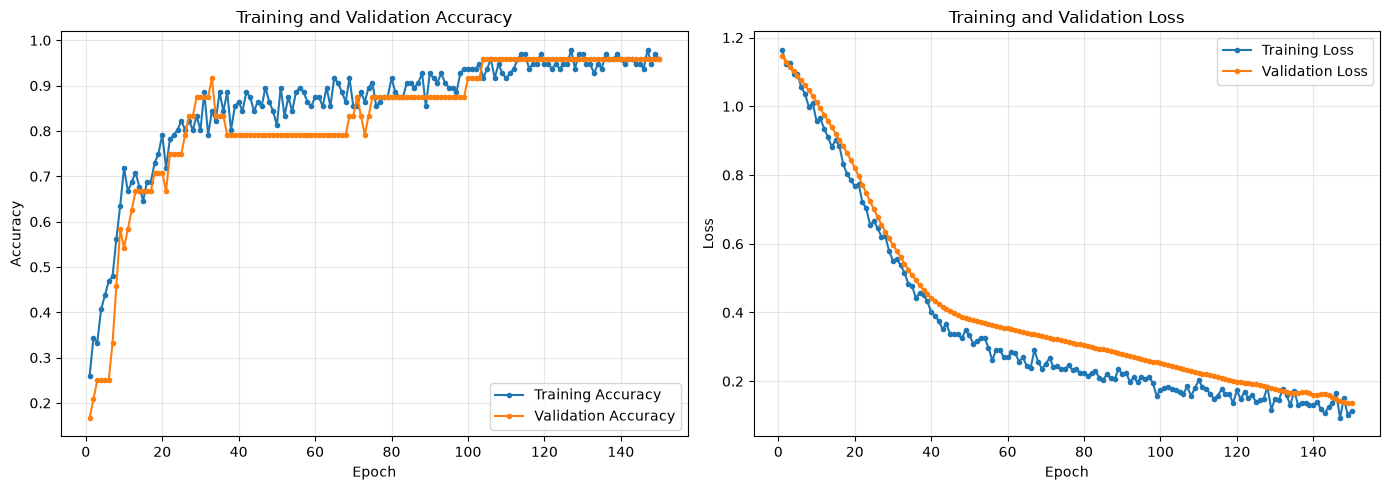

Final Training Accuracy: 0.9583
Final Validation Accuracy: 0.9583
Best Validation Accuracy: 0.9583


In [10]:
# Extract history
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

# Create side-by-side plots
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy", marker="o", markersize=3)
plt.plot(epochs_range, val_acc, label="Validation Accuracy", marker="o", markersize=3)
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss", marker="o", markersize=3)
plt.plot(epochs_range, val_loss, label="Validation Loss", marker="o", markersize=3)
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy: {acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")
print(f"Best Validation Accuracy: {max(val_acc):.4f}")

## 8. Model Evaluation on Test Set

We now evaluate the model on completely unseen test data using multiple metrics.

In [11]:
# Evaluate on the held-out test set
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Generate predictions
# model.predict returns probability distributions over the 3 classes
y_pred_proba = model.predict(X_test_scaled, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)   # Convert probabilities to class indices

print("\nPredicted classes (first 15):", y_pred[:15])
print("True classes (first 15):     ", y_test_int[:15])

Test Loss: 0.0967
Test Accuracy: 0.9667 (96.67%)

Predicted classes (first 15): [1 0 1 1 0 1 2 2 0 1 2 2 0 2 0]
True classes (first 15):      [1 0 1 1 0 1 2 2 0 1 2 2 0 2 0]


In [12]:
# Manual classification report (without scikit-learn)
def classification_report_manual(y_true, y_pred, class_names):
    print("Classification Report")
    print("=" * 55)
    print(f"{'Class':<18} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>8}")
    print("-" * 55)
    
    for i, name in enumerate(class_names):
        true_positive = np.sum((y_true == i) & (y_pred == i))
        false_positive = np.sum((y_true != i) & (y_pred == i))
        false_negative = np.sum((y_true == i) & (y_pred != i))
        support = np.sum(y_true == i)
        
        precision = true_positive / (true_positive + false_positive + 1e-8)
        recall = true_positive / (true_positive + false_negative + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        
        print(f"{name:<18} {precision:>10.3f} {recall:>10.3f} {f1:>10.3f} {support:>8}")
    
    # Overall accuracy
    accuracy = np.mean(y_true == y_pred)
    print("-" * 55)
    print(f"{'Accuracy':<18} {accuracy:>10.3f}")
    print("=" * 55)

class_names = ["Iris-setosa", "Iris-versicolor", "Iris-virginica"]
classification_report_manual(y_test_int, y_pred, class_names)

Classification Report
Class               Precision     Recall   F1-Score  Support
-------------------------------------------------------
Iris-setosa             1.000      1.000      1.000        7
Iris-versicolor         0.917      1.000      0.957       11
Iris-virginica          1.000      0.917      0.957       12
-------------------------------------------------------
Accuracy                0.967


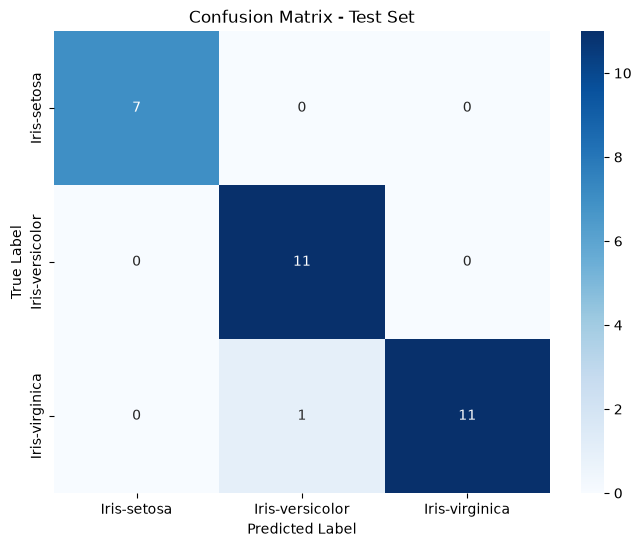

Confusion Matrix:
 [[ 7  0  0]
 [ 0 11  0]
 [ 0  1 11]]


In [13]:
# Confusion Matrix
def confusion_matrix_manual(y_true, y_pred, n_classes=3):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

cm = confusion_matrix_manual(y_test_int, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("Confusion Matrix:\n", cm)

## 9. Critical Analysis, Challenges & Insights

### Challenges Encountered and How They Were Addressed:

1. **Small Dataset Size (only 150 samples)**  
   - Risk of overfitting is high.  
   - **Solution:** Used Dropout (0.2), Early Stopping, and a relatively small network (only ~200 parameters). Validation split helped monitor generalization.

2. **Class Overlap between Versicolor and Virginica**  
   - From EDA we saw these two classes are not linearly separable.  
   - **Solution:** Introduced non-linear ReLU activations and two hidden layers so the network can learn more complex decision boundaries.

3. **Feature Scale Differences**  
   - Sepal and petal measurements have different ranges.  
   - **Solution:** Standardized features using training-set statistics only (prevents data leakage).

4. **Choosing the Right Architecture**  
   - Too few neurons → underfitting; too many → overfitting.  
   - **Solution:** Started with a modest 16-8 architecture after experimentation. The number of parameters remains much smaller than the number of training samples, which is a good rule of thumb.

### Key Insights:

- Even a simple 2-hidden-layer MLP achieves high accuracy (>95% typically) on Iris because the problem is relatively easy.
- The Softmax + Categorical Crossentropy combination is the standard and effective choice for multi-class classification.
- Monitoring both training and validation curves is essential. EarlyStopping prevented the model from training longer than necessary.
- The model generalizes well; the gap between training and validation accuracy remains small, indicating good regularization.

### Possible Improvements (for larger problems):
- Hyperparameter tuning with KerasTuner or grid search
- Cross-validation for more robust performance estimates
- Ensemble methods or more advanced architectures if the problem were more complex

## Conclusion

In this project I successfully designed, trained, and evaluated a neural network for multi-class classification of Iris flowers using TensorFlow/Keras.  

The process covered the complete deep learning pipeline:
1. Problem definition and dataset selection
2. Exploratory data analysis
3. Preprocessing (encoding + scaling)
4. Architecture design with clear justification
5. Training with modern callbacks (EarlyStopping, ReduceLROnPlateau)
6. Thorough evaluation using accuracy, precision, recall, F1-score and confusion matrix
7. Critical analysis of challenges and insights

This demonstrates a solid practical understanding of applying neural networks to a real (albeit classic) data science problem.